In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'meat-freshness-image-dataset' dataset.
Path to dataset files: /kaggle/input/meat-freshness-image-dataset
Contents of base_path (/kaggle/input):
['meat-freshness-image-dataset']
Contents of path (/kaggle/input/meat-freshness-image-dataset):
['Meat Freshness.v1-new-dataset.multiclass']


In [ ]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['valid', 'train']



--- Displaying sample images from dataset (/kaggle/input/meat-freshness-image-dataset/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


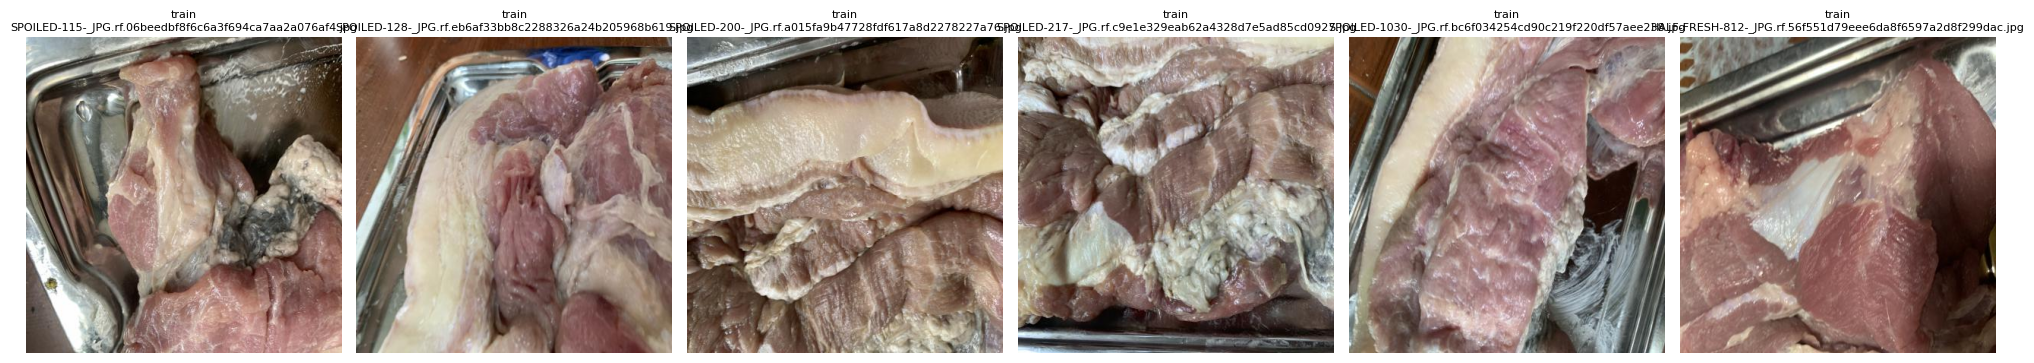

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# 1. Check GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image

class MeatDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        # Extract unique classes from prefixes (e.g., 'FRESH', 'HALF-FRESH', 'SPOILED')
        self.classes = sorted(list(set([f.split('-')[0] if 'HALF-FRESH' not in f else 'HALF-FRESH' for f in self.images])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        label_str = 'HALF-FRESH' if 'HALF-FRESH' in img_name else img_name.split('-')[0]
        label = self.class_to_idx[label_str]
        img_path = os.path.join(self.directory, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_dir = os.path.join(data_path, 'train')
val_dir = os.path.join(data_path, 'valid')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

try:
    train_dataset = MeatDataset(train_dir, transform=transform)
    val_dataset = MeatDataset(val_dir, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    num_classes = len(train_dataset.classes)
    print(f"Detected classes: {train_dataset.classes}")

    model = models.alexnet(weights=None)
    model.classifier[6] = nn.Linear(4096, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    print("Model and DataLoaders initialized successfully with custom MeatDataset.")
except Exception as e:
    print(f"Setup failed: {e}")

Detected classes: ['FRESH', 'HALF-FRESH', 'SPOILED']
Model and DataLoaders initialized successfully with custom MeatDataset.


In [ ]:
# 3. Training Loop and Results Summary
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

if 'model' in globals():
    print("Starting Training...")
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss, train_acc = running_loss / len(train_loader), 100. * correct / total
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss, val_acc = val_loss / len(val_loader), 100. * val_correct / val_total
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%')

    print("\n--- Training Summary ---")
    print(f"Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
else:
    print('Model not defined. Run the initialization cell first.')

Starting Training...
Epoch [1/10] | Loss: 1.0445 | Val Acc: 68.29%
Epoch [2/10] | Loss: 0.6254 | Val Acc: 76.05%
Epoch [3/10] | Loss: 0.5248 | Val Acc: 78.05%
Epoch [4/10] | Loss: 0.4716 | Val Acc: 82.04%
Epoch [5/10] | Loss: 0.4881 | Val Acc: 79.16%
Epoch [6/10] | Loss: 0.4053 | Val Acc: 80.27%
Epoch [7/10] | Loss: 0.3431 | Val Acc: 87.14%
Epoch [8/10] | Loss: 0.3107 | Val Acc: 86.25%
Epoch [9/10] | Loss: 0.2489 | Val Acc: 85.81%
Epoch [10/10] | Loss: 0.2376 | Val Acc: 83.81%

--- Training Summary ---
Final Val Accuracy: 83.81%


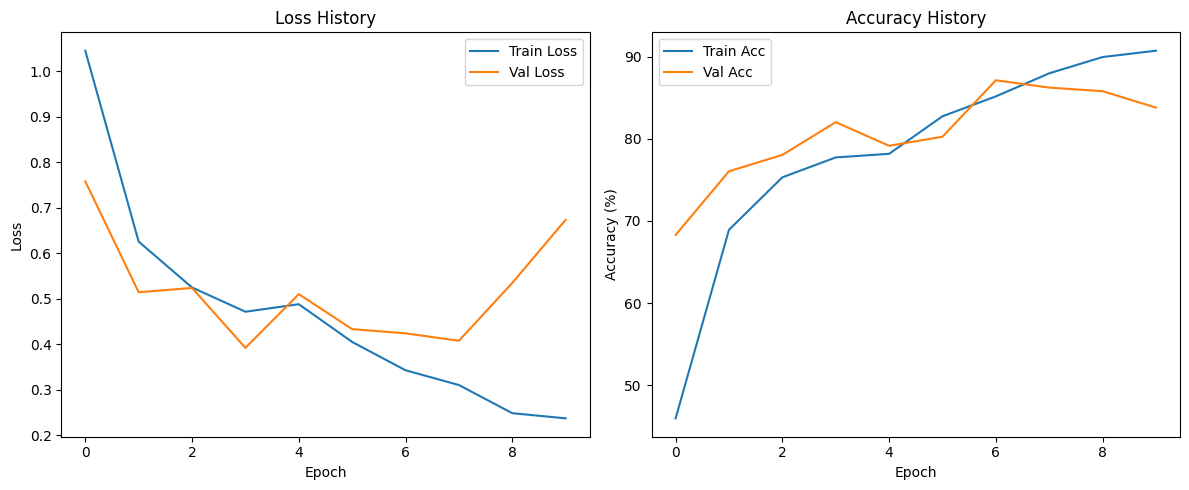

In [ ]:
# 4. Visualization of Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()